### Config

In [466]:
data_root_path = "/media/data/minhht/moe_plantdeasse/data/tomato_only"
checkpoint_path = "/media/data/minhht/moe_plantdeasse/notebook/mobilenetv3_large.pth"
num_classes = 8

### Load Dataset

In [467]:
"""
Utility Functions and Dataset Loading Classes.

This module provides helper functions and dataset classes for loading and processing
plant disease images. It includes the LoadDataset class for structured data loading
with support for train/validation/test splits.

Key Features:
    - Automatic dataset splitting with stratification
    - Class to index mapping for label encoding
    - Image loading with PIL
    - Transform pipeline support via Albumentations
"""

import os
from typing import List, Tuple, Dict, Literal, Optional
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision.transforms import transforms

from PIL import Image
from sklearn.model_selection import train_test_split


class LoadDataset(Dataset):
    """
    Dataset loader for plant disease classification.
    
    Loads images from a structured directory of disease classes and provides
    automatic train/validation/test splitting with stratification to ensure
    balanced class distribution across splits.
    
    The dataset expects a directory structure like:
        root_dir/
        ├── Tomato_Bacterial_spot/
        ├── Tomato_Early_blight/
        ├── Tomato_healthy/
        └── ... (other disease classes)
    
    Attributes:
        root_dir (Path): Root directory containing disease class folders
        split (str): Dataset split ('train', 'val', or 'test')
        train_ratio (float): Proportion of data for training
        image_paths (List[str]): List of image file paths for the selected split
        labels (List[int]): Class labels corresponding to image_paths
        class_to_idx (Dict[str, int]): Mapping from class name to class index
        idx_to_class (Dict[int, str]): Mapping from class index to class name
    """

    def __init__(
        self,
        root_dir: Path,
        split: Literal['train', 'validation', 'test'],
        train_ratio: float = 0.8,
        transform: transforms.Compose = None
    ) -> None:
        """
        Initialize the dataset loader.
        
        Args:
            root_dir (Path): Root directory containing class subdirectories
            split (str, optional): Dataset split - 'train', 'val', or 'test'. Defaults to 'train'.
            train_ratio (float, optional): Proportion of data for training (0 to 1). Defaults to 0.8.
            transform (transforms.Compose, optional): Image transformation pipeline. Defaults to None.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.split = split
        self.train_ratio = train_ratio
        self.image_paths, self.labels, self.class_to_idx, self.idx_to_class = self._split_dataset()

    def _load_image(self, root_dir: Path) -> Tuple[List[str], List[int], Dict[str, int], Dict[int, str]]:
        """
        Load all images and labels from the root directory.
        
        Scans the root directory for subdirectories starting with "Tomato" (disease classes),
        collects all image files from each class, and creates class-to-index mappings.
        
        Args:
            root_dir (Path): Root directory containing class subdirectories
            
        Returns:
            Tuple containing:
                - image_paths (List[str]): Absolute paths to all image files
                - labels (List[int]): Class labels (0-indexed) corresponding to each image
                - class_to_idx (Dict[str, int]): Mapping from class name to class index
                - idx_to_class (Dict[int, str]): Mapping from class index to class name
        """
        class_names = sorted(
            [d for d in os.listdir(root_dir)
             if os.path.isdir(os.path.join(root_dir, d))
             and d.startswith("Tomato")]
        )
        class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
        idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
        image_paths = []
        labels = []
        for class_name in class_names:
            dir = os.path.join(root_dir, class_name)
            for fname in os.listdir(dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(dir, fname))
                    labels.append(class_to_idx[class_name])
        return image_paths, labels, class_to_idx, idx_to_class

    def _split_dataset(self) -> Tuple[List[str], List[int], Dict[str, int], Dict[int, str]]:
        """
        Split dataset into train, validation, and test sets.
        
        Uses stratified sampling to ensure balanced class distribution across all splits:
        - 80% training, 20% temporary (from train_ratio)
        - Temporary split: 50% validation, 50% test
        
        Returns:
            Tuple containing:
                - image_paths (List[str]): Image paths for the selected split
                - labels (List[int]): Labels for the selected split
                - class_to_idx (Dict[str, int]): Class name to index mapping
                - idx_to_class (Dict[int, str]): Index to class name mapping
                
        Raises:
            ValueError: If split is not 'train', 'val', or 'test'
        """
        image_paths, labels, class_to_idx, idx_to_class = self._load_image(self.root_dir)

        train_paths, test_paths, train_labels, test_labels = train_test_split(
            image_paths, labels, test_size= 1-self.train_ratio, stratify=labels, random_state=42, shuffle=True
        )

        if self.split == 'train':
            return train_paths, train_labels, class_to_idx, idx_to_class
        elif self.split == 'test':
            return test_paths, test_labels, class_to_idx, idx_to_class
        else:
            raise ValueError("split must be 'train' or 'test'")

    def __len__(self) -> int:
        """
        Return the total number of samples in this dataset split.
        
        Returns:
            int: Number of images in the current split
        """
        return len(self.image_paths)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        """
        Get a single sample from the dataset by index.
        
        Loads an image from disk, applies transformations if specified, and returns
        the transformed image tensor and its corresponding class label.
        
        Args:
            idx (int): Index of the sample to retrieve
            
        Returns:
            Tuple containing:
                - image (torch.Tensor): Transformed image tensor
                - label (int): Class label (0-indexed)
        """
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(image_path).convert('RGB')
        image = np.array(image)
        if self.transform:
            augumented = self.transform(image=image)
            image = augumented["image"]
        return image, label


In [468]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform_pipeline = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

train_dataset = LoadDataset(data_root_path, split='train', train_ratio=0.8, transform=transform_pipeline)
test_dataset = LoadDataset(data_root_path, split='test', train_ratio=0.8, transform=transform_pipeline)

print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))
print("Class to index mapping:", train_dataset.class_to_idx)

Number of training samples: 2274
Number of test samples: 569
Class to index mapping: {'Tomato Early blight leaf': 0, 'Tomato Septoria leaf spot': 1, 'Tomato leaf': 2, 'Tomato leaf bacterial spot': 3, 'Tomato leaf late blight': 4, 'Tomato leaf mosaic virus': 5, 'Tomato leaf yellow virus': 6, 'Tomato mold leaf': 7}


In [469]:
from torch.utils.data import DataLoader


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Backbone Feature Extractor

In [470]:
import torch
import torch.nn as nn
from torchvision import models

model = models.mobilenet_v3_large(pretrained=True)

# thay classifier
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, 8)

model.load_state_dict(torch.load(checkpoint_path, map_location="cuda"))
model.classifier = nn.Identity()
model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [471]:
dummy_input = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    features = model(dummy_input)
print("Extracted features shape:", features.shape)

Extracted features shape: torch.Size([1, 960])


In [472]:
train_features = []
train_labels = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        features = model(images)
        train_features.append(features.cpu())
        train_labels.append(labels.cpu())

train_features_all = torch.cat(train_features)
train_labels_all = torch.cat(train_labels)
print("Train features shape:", train_features_all.shape)
print("Train labels shape:", train_labels_all.shape)

Train features shape: torch.Size([2274, 960])
Train labels shape: torch.Size([2274])


### Normalize Features

In [473]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
train_features_normalized = sc.fit_transform(train_features_all)
print("Normalized train features shape:", train_features_normalized.shape)

Normalized train features shape: (2274, 960)


### Reduce dimentions with PCA

In [474]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
train_features_pca = pca.fit_transform(train_features_normalized)
print("PCA-reduced features shape:", train_features_pca.shape)

PCA-reduced features shape: (2274, 10)


### Kmeans Clustering

In [475]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)
clusters_labels_kmeans = kmeans.fit_predict(train_features_pca)
score = silhouette_score(train_features_pca, clusters_labels_kmeans)
print("Silhouette_kmeans:", score)

Silhouette_kmeans: 0.15848969372992136


In [476]:
import joblib

joblib.dump(kmeans, "kmeans_pca_3clusters.pkl")

['kmeans_pca_3clusters.pkl']

### Post Process Clustering

[[17.07119138 -2.44162923  0.29160742 -0.47983342  0.56354089 -0.09256685
  -0.24707978  0.14650496 -0.31974893 -0.04653226]
 [-1.95969524  6.99234774 -1.25201323 -0.80047291 -0.51670803  0.18861103
   0.28688661  0.26712435  0.43669699  0.1656086 ]
 [-8.2509262  -4.98433921  0.97817934  1.01766812  0.14276401 -0.11872358
  -0.11801096 -0.3315857  -0.21281441 -0.12470093]]


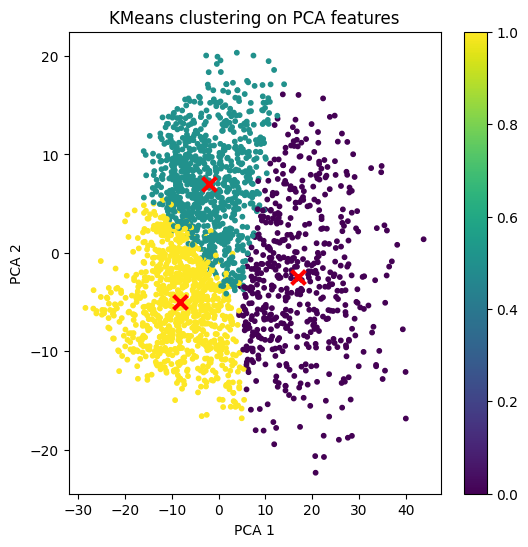

In [477]:
import matplotlib.pyplot as plt


centroids = kmeans.cluster_centers_
print(centroids)
    
plt.figure(figsize=(6,6))
plt.scatter(train_features_pca[:,0], train_features_pca[:,1], 
            c=clusters_labels_kmeans, cmap='viridis', s=10)
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='x', s=100, linewidths=3)

plt.title("KMeans clustering on PCA features")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar()
plt.show()

In [478]:
import numpy as np

unique, counts = np.unique(clusters_labels_kmeans, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} samples")

Cluster 0: 534 samples
Cluster 1: 833 samples
Cluster 2: 907 samples


In [479]:
print("Shape of cluster kmeans is: ", clusters_labels_kmeans.shape)

Shape of cluster kmeans is:  (2274,)


In [480]:
import pandas as pd

df = pd.DataFrame({
    "cluster": clusters_labels_kmeans,
    "label": train_labels_all.numpy()
})

print(pd.crosstab(df["cluster"], df["label"]))

label     0    1    2   3   4    5    6    7
cluster                                     
0        76  177   33  68  96   13   24   47
1        64  103  231  98  69   52  106  110
2        25   57   54  44  11  144  503   69


In [481]:
import numpy as np

clusters = {}

for i in range(3):
    idx = np.where(clusters_labels_kmeans == i)[0]

    clusters[i] = {
        "features": train_features_all[idx],
        "labels": train_labels_all[idx]
    }

    print(f"Cluster {i}: {len(idx)} samples")

Cluster 0: 534 samples
Cluster 1: 833 samples
Cluster 2: 907 samples


### Trainning Experts

In [482]:
import torch
from torch.utils.data import Dataset

class FeatureDataset(Dataset):

    def __init__(self, features, labels):
        super().__init__()
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [483]:
from torch.utils.data import DataLoader

cluster_loaders = []

for i in range(3):

    dataset = FeatureDataset(
        clusters[i]["features"],
        clusters[i]["labels"]
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=True
    )

    cluster_loaders.append(loader)

In [484]:
import torch.nn as nn

class Expert(nn.Module):

    def __init__(self, input_dim, num_classes):

        super().__init__()

        self.expert = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)

        )

    def forward(self, x):
        return self.expert(x)

In [485]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = train_features_all.shape[1]
num_classes = len(torch.unique(train_labels_all))
print("Num classes of Expert are: ", num_classes)

experts = []

for i in range(3):

    model = Expert(input_dim, num_classes).to(device)
    experts.append(model)

Num classes of Expert are:  8


In [486]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

criterion = nn.CrossEntropyLoss()

for i in range(3):

    print(f"\nTraining Expert {i}")

    # dataset của cluster i
    dataset = FeatureDataset(
        clusters[i]["features"],
        clusters[i]["labels"]
    )

    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    # model riêng
    model = Expert(input_dim, num_classes).to(device)

    # optimizer riêng
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(10):

        total_loss = 0

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}")

    # lưu expert
    torch.save(model.state_dict(), f"expert_{i}.pth")

    # giải phóng GPU
    del model
    torch.cuda.empty_cache()


Training Expert 0
Epoch 1 Loss: 1.6563
Epoch 2 Loss: 1.2218
Epoch 3 Loss: 0.9233
Epoch 4 Loss: 0.6658
Epoch 5 Loss: 0.4890
Epoch 6 Loss: 0.3314
Epoch 7 Loss: 0.1997
Epoch 8 Loss: 0.1444
Epoch 9 Loss: 0.0913
Epoch 10 Loss: 0.0575

Training Expert 1
Epoch 1 Loss: 1.7570
Epoch 2 Loss: 1.2427
Epoch 3 Loss: 1.1005
Epoch 4 Loss: 0.8547
Epoch 5 Loss: 0.7228
Epoch 6 Loss: 0.5981
Epoch 7 Loss: 0.5027
Epoch 8 Loss: 0.3966
Epoch 9 Loss: 0.2443
Epoch 10 Loss: 0.1638

Training Expert 2
Epoch 1 Loss: 1.3248
Epoch 2 Loss: 0.9136
Epoch 3 Loss: 0.6976
Epoch 4 Loss: 0.5382
Epoch 5 Loss: 0.3648
Epoch 6 Loss: 0.2957
Epoch 7 Loss: 0.2113
Epoch 8 Loss: 0.1337
Epoch 9 Loss: 0.0875
Epoch 10 Loss: 0.1456


### Validation

In [487]:
import joblib

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torchvision import models

import warnings
warnings.filterwarnings("ignore")


# __________________Load Backbone______________________________________
model = models.mobilenet_v3_large(pretrained=True)
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, 8)

model.load_state_dict(torch.load(checkpoint_path, map_location="cuda"))
model.classifier = nn.Identity()
model.eval()

# __________________Load Kmeans_________________________________________
kmeans = joblib.load("kmeans_pca_3clusters.pkl")

# __________________Features Extration__________________________________
val_features = []
val_labels = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Availabel device is: ', device)
model.to(device)
with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        features = model(images)

        val_features.append(features.cpu())
        val_labels.append(labels.cpu())   # sửa ở đây

val_features_all = torch.cat(val_features)
val_labels_all = torch.cat(val_labels)
print("Val features shape:", val_features_all.shape)
print("Val labels shape:", val_labels_all.shape)

# _____________________Normalize features______________________________
sc = StandardScaler()
val_features_normalized = sc.fit_transform(val_features_all)
# _____________________PCA reduce dimentions__________________________
features_pca = pca.fit_transform(val_features_normalized)

# ____________________Routing___________________________________________
val_clusters = kmeans.predict(features_pca)
print(val_clusters)
experts = []

for i in range(3):

    expert = Expert(input_dim, num_classes)
    expert.load_state_dict(torch.load(f"expert_{i}.pth"))
    expert.to(device)
    expert.eval()

    experts.append(expert)

# _________________________Predict______________________________________
y_pred = []

for i in range(len(val_features_all)):

    feature = torch.tensor(val_features_all[i]).float().unsqueeze(0).to(device)

    cluster_id = val_clusters[i]

    expert = experts[cluster_id]

    output = expert(feature)

    pred = torch.argmax(output, dim=1).item()

    y_pred.append(pred)

Availabel device is:  cuda
Val features shape: torch.Size([569, 960])
Val labels shape: torch.Size([569])
[2 0 0 0 2 0 2 2 2 0 2 2 1 2 0 1 0 1 1 0 1 1 0 1 0 1 0 2 2 1 2 1 2 1 1 1 2
 1 0 2 0 0 1 1 1 1 2 2 1 2 1 1 1 2 2 0 1 0 1 2 1 1 1 1 2 2 1 1 2 2 2 0 2 2
 0 0 1 0 1 0 0 2 2 1 2 0 1 2 0 2 1 0 0 2 2 2 2 0 1 1 2 1 2 2 2 0 2 0 0 2 2
 2 0 0 1 2 0 0 1 1 2 1 2 0 0 0 2 0 1 0 2 1 0 2 2 1 2 2 0 2 2 1 0 2 0 1 0 0
 0 1 0 1 1 0 1 2 2 0 1 2 2 2 1 1 2 0 2 2 2 2 2 1 2 2 0 1 1 0 0 2 2 2 2 1 0
 1 2 2 1 2 0 0 2 2 2 2 2 1 2 2 0 0 0 0 2 1 0 2 0 1 1 2 2 0 2 1 0 1 1 1 2 2
 2 1 2 1 1 2 0 1 1 1 0 2 2 2 1 2 2 2 1 1 1 2 2 1 2 0 2 2 1 2 1 2 0 0 1 2 1
 2 2 2 0 0 2 2 2 2 1 2 1 1 1 0 0 1 1 0 0 2 2 2 1 0 2 0 1 2 1 2 1 1 2 2 1 2
 2 2 1 1 1 0 2 1 2 1 1 2 1 0 0 1 1 0 2 2 0 1 2 1 2 1 2 2 1 2 1 2 0 2 2 1 0
 2 1 2 0 0 0 1 1 1 0 0 1 1 1 1 1 1 1 2 2 1 1 1 0 0 2 1 2 2 1 1 2 2 1 2 2 2
 2 2 2 0 2 0 2 2 0 2 0 1 0 1 1 2 1 2 2 1 2 2 2 0 1 2 1 0 2 0 1 2 2 2 0 2 1
 1 2 0 0 2 1 0 2 2 2 0 2 2 0 0 1 1 1 0 1 1 0 0 2 2 2 1 0 2 1 2 0 2 1 

In [488]:
from sklearn.metrics import classification_report

print(classification_report(val_labels_all.numpy(), y_pred))

              precision    recall  f1-score   support

           0       0.56      0.44      0.49        41
           1       0.62      0.76      0.68        84
           2       0.69      0.80      0.74        80
           3       0.60      0.40      0.48        53
           4       0.68      0.64      0.66        44
           5       0.52      0.63      0.57        52
           6       0.88      0.88      0.88       158
           7       0.68      0.53      0.59        57

    accuracy                           0.70       569
   macro avg       0.66      0.63      0.64       569
weighted avg       0.70      0.70      0.69       569

